# Entrenamiento de un Modelo de Deep Learning de Inicio a Fin

In [1]:
!pip install torch torchvision numpy matplotlib scikit-learn

## Data set

### Carga del data set

In [2]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
 transforms.ToTensor(),
 transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

print("Tamaño del set de entrenamiento:", len(train_data))
print("Tamaño del set de prueba:", len(test_data))


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.16MB/s]

Tamaño del set de entrenamiento: 60000
Tamaño del set de prueba: 10000


### Visualizacion del data set

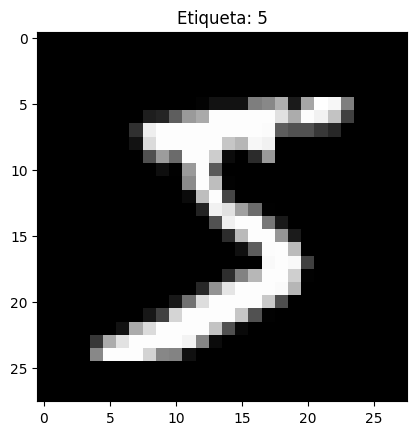

In [3]:
import matplotlib.pyplot as plt

image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Etiqueta: {label}")
plt.show()


## Preparacion del dataset

In [4]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)


## Definición del modelo

In [5]:
import torch.nn as nn

model = nn.Sequential(
 nn.Flatten(),
 nn.Linear(28*28, 128),
 nn.ReLU(),
 nn.Dropout(0.2),
 nn.Linear(128, 64),
 nn.ReLU(),
 nn.Linear(64, 10)
)


## Configuración de la función de pérdida y optimizador

In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## Entrenamiento del modelo

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validación
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            val_loss += criterion(output, labels).item()

            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    accuracy = correct / total

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Loss: {train_losses[-1]:.4f}, "
        f"Val Loss: {val_losses[-1]:.4f}, "
        f"Val Accuracy: {accuracy:.4f}"
    )


Epoch 1/10, Train Loss: 0.4646, Val Loss: 0.2452, Val Accuracy: 0.9240
Epoch 2/10, Train Loss: 0.2394, Val Loss: 0.1826, Val Accuracy: 0.9424
Epoch 3/10, Train Loss: 0.1924, Val Loss: 0.1438, Val Accuracy: 0.9580
Epoch 4/10, Train Loss: 0.1665, Val Loss: 0.1395, Val Accuracy: 0.9570
Epoch 5/10, Train Loss: 0.1496, Val Loss: 0.1324, Val Accuracy: 0.9601
Epoch 6/10, Train Loss: 0.1392, Val Loss: 0.1146, Val Accuracy: 0.9665
Epoch 7/10, Train Loss: 0.1268, Val Loss: 0.1150, Val Accuracy: 0.9652
Epoch 8/10, Train Loss: 0.1219, Val Loss: 0.1127, Val Accuracy: 0.9660
Epoch 9/10, Train Loss: 0.1148, Val Loss: 0.1043, Val Accuracy: 0.9676
Epoch 10/10, Train Loss: 0.1088, Val Loss: 0.1169, Val Accuracy: 0.9630


## Validación y evaluación del modelo

### K-Fold Cross Validation

In [8]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
X = torch.stack([train_data[i][0] for i in range(len(train_data))])
y = torch.tensor([train_data[i][1] for i in range(len(train_data))])


### Métricas de evaluación

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
 for images, labels in test_loader:
  images = images.to(device)
  output = model(images)
  _, preds = torch.max(output, 1)
  all_preds.extend(preds.cpu())
  all_labels.extend(labels)

print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.91      0.98      0.95      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.93      0.95       982
           5       0.98      0.94      0.96       892
           6       0.98      0.97      0.97       958
           7       0.95      0.97      0.96      1028
           8       0.98      0.94      0.96       974
           9       0.95      0.96      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.97      0.96      0.96     10000



Matriz de confusion

<Axes: >

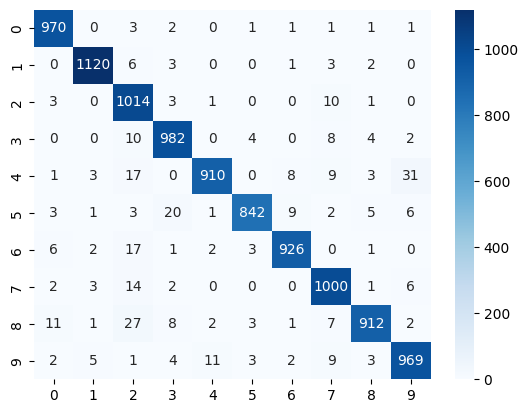

In [10]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Fine-Tuning con modelo preentrenado

In [11]:
from torchvision import models

model_ft = models.resnet18(pretrained=True)

# Congelar todas las capas
for param in model_ft.parameters():
 param.requires_grad = False

# Reemplazar capa final
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 10) # 10 clases

model_ft.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Entrenamiento:

In [12]:
optimizer = optim.Adam(model_ft.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Entrenamiento similar al anterior pero solo con la capa final


Para un fine-tuning completo:

In [13]:
for param in model_ft.parameters():
 param.requires_grad = True

optimizer = optim.Adam(model_ft.parameters(), lr=1e-5)


## Guardar y reutilizar el modelo

In [14]:
torch.save(model.state_dict(), "modelo_final.pth")


Para cargarlo después:

In [ ]:
model.load_state_dict(torch.load("modelo_final.pth"))
model.eval()
